# Практика: логистическая регрессия с нуля и сравнение со `scikit-learn`

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и изучите бинарный датасет;
2. подготовите данные для обучения;
3. реализуете ключевые части логистической регрессии **с нуля**:
   - сигмоиду,
   - log-loss,
   - градиентный спуск,
   - предсказание вероятностей и классов;
4. обучите свою модель;
5. сравните её качество и коэффициенты с реализацией из `scikit-learn`;
6. поэкспериментируете с порогом классификации.

## Важно
- Сначала дописывайте пропуски в **своей** реализации.
- Только после этого переходите к сравнению со `scikit-learn`.
- Не удаляйте проверки и комментарии: они помогают вам понять ход решения.

## Датасет
Мы используем `Breast Cancer Wisconsin` из `sklearn.datasets`:
- задача **бинарной классификации**;
- признаки числовые;
- датасет удобен для изучения логистической регрессии без сложной предобработки категориальных переменных.

## Что сдавать
1. Заполненный ноутбук.
2. Краткие выводы в конце:
   - насколько близки метрики вашей модели и `scikit-learn`;
   - где ваша реализация может уступать библиотечной;
   - как влияет изменение порога классификации.

## Коротко о теории

### 1. Логистическая регрессия
Логистическая регрессия моделирует вероятность положительного класса:

\[
P(y=1 \mid x) = \sigma(z), \quad z = w^T x + b
\]

где \(\sigma(z)\) — сигмоида:

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

### 2. Почему не линейная регрессия
Если предсказывать класс линейной моделью напрямую, прогноз может выйти за диапазон \([0, 1]\).  
Сигмоида решает эту проблему: она переводит любое число в вероятность.

### 3. Функция потерь
Для логистической регрессии используется **log-loss**:

\[
L = - \frac{1}{n} \sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)
\right]
\]

### 4. Обучение
Мы будем минимизировать log-loss методом **градиентного спуска**.

### 5. Что будем сравнивать
После своей реализации вы сравните результат с `sklearn.linear_model.LogisticRegression`:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

### 6. Почему нужна стандартизация
Градиентный спуск работает стабильнее, когда признаки находятся примерно в одном масштабе.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Размер X:", X.shape)
print("Размер y:", y.shape)
display(X.head())
display(y.value_counts().rename(index={0: "malignant", 1: "benign"}))

Размер X: (569, 30)
Размер y: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


target
benign       357
malignant    212
Name: count, dtype: int64

Пропуски по признакам:


mean radius             0
mean texture            0
worst symmetry          0
worst concave points    0
worst concavity         0
dtype: int64


Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


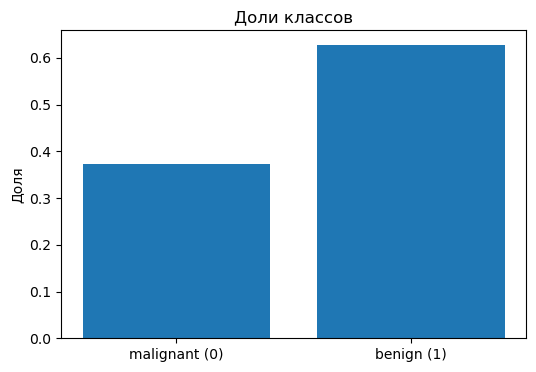

In [3]:
print("Пропуски по признакам:")
display(X.isna().sum().sort_values(ascending=False).head())

print("\nБазовая статистика:")
display(X.describe().T.head(10))

class_share = y.value_counts(normalize=True).sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["malignant (0)", "benign (1)"], class_share.values)
plt.title("Доли классов")
plt.ylabel("Доля")
plt.show()

## Шаг 1. Разделение данных и стандартизация

Ниже нужно:
1. разбить выборку на train и test;
2. стандартизовать признаки только по train-части;
3. получить `X_train_scaled` и `X_test_scaled`.

Подсказка:
- используйте `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`;
- `StandardScaler().fit(...)` делаем **только на train**.

In [4]:
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)


Train shape: (455, 30)
Test shape: (114, 30)


## Шаг 2. Реализуем сигмоиду

Допишите функцию `sigmoid(z)`.

Проверка:
- `sigmoid(0)` должно быть равно `0.5`;
- функция должна работать и со скалярами, и с `numpy`-массивами.

In [5]:
def sigmoid(z):
    # YOUR CODE HERE
    return 1.0 / (1.0 + np.exp(-z))

print("sigmoid(0) =", sigmoid(0))
print("sigmoid([-1, 0, 1]) =", sigmoid(np.array([-1.0, 0.0, 1.0])))


sigmoid(0) = 0.5
sigmoid([-1, 0, 1]) = [0.26894142 0.5        0.73105858]


## Шаг 3. Реализуем log-loss

Напишите функцию `compute_log_loss(y_true, y_pred_proba)`.

Важно:
- чтобы избежать `log(0)`, используйте `np.clip(y_pred_proba, 1e-15, 1 - 1e-15)`.

In [6]:
def compute_log_loss(y_true, y_pred_proba):
    # YOUR CODE HERE
    p = np.clip(y_pred_proba, 1e-15, 1 - 1e-15)
    loss = -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))
    return loss

toy_y = np.array([0, 1, 1, 0])
toy_p = np.array([0.1, 0.9, 0.8, 0.3])
print("Toy log-loss:", compute_log_loss(toy_y, toy_p))


Toy log-loss: 0.19763488164214868


## Шаг 4. Один шаг градиентного спуска

Напомним:
- \(z = Xw + b\)
- \(\hat{p} = \sigma(z)\)

Градиенты для log-loss:
\[
dw = rac{1}{n} X^T(\hat{p} - y), \qquad db = rac{1}{n}\sum(\hat{p} - y)
\]

Ниже нужно реализовать функцию, которая считает:
- вероятности,
- loss,
- градиенты `dw`, `db`.

In [7]:
def forward_backward(X, y, w, b):
    # YOUR CODE HERE
    n = X.shape[0]
    z  = X @ w + b          # (n,)
    p  = sigmoid(z)          # (n,)
    loss = compute_log_loss(y, p)
    diff = p - y             # (n,)
    dw = (X.T @ diff) / n   # (n_features,)
    db = diff.mean()
    return p, loss, dw, db

n_features = X_train_scaled.shape[1]
w0 = np.zeros(n_features)
b0 = 0.0

p0, loss0, dw0, db0 = forward_backward(X_train_scaled, y_train.values, w0, b0)
print("Initial loss:", loss0)
print("dw shape:", dw0.shape)
print("db:", db0)


Initial loss: 0.6931471805599453
dw shape: (30,)
db: -0.12637362637362637


## Шаг 5. Собираем модель в класс

Допишите методы:
- `fit`
- `predict_proba`
- `predict`

Требования:
- обучение через градиентный спуск;
- сохранять историю значения loss;
- в `predict` использовать порог `threshold`.

In [8]:
class MyLogisticRegressionGD:
    def __init__(self, learning_rate=0.05, n_iters=3000, threshold=0.5):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.threshold = threshold
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        # YOUR CODE HERE
        n_features = X.shape[1]
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.loss_history = []

        for _ in range(self.n_iters):
            _, loss, dw, db = forward_backward(X, y, self.w, self.b)
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            self.loss_history.append(loss)

        return self

    def predict_proba(self, X):
        # YOUR CODE HERE
        z = X @ self.w + self.b
        proba = sigmoid(z)
        return proba

    def predict(self, X):
        # YOUR CODE HERE
        proba = self.predict_proba(X)
        preds = (proba >= self.threshold).astype(int)
        return preds


## Шаг 6. Обучаем свою модель

Попробуйте обучить свою модель и посмотрите:
- уменьшается ли `loss`;
- какое качество получается на test.

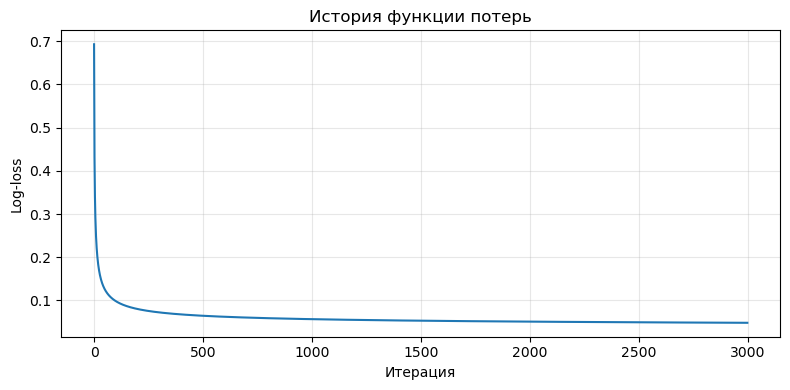

Финальный loss: 0.0482


In [9]:
my_model = MyLogisticRegressionGD(
    learning_rate=0.1,
    n_iters=3000,
    threshold=0.5
)

# YOUR CODE HERE
my_model.fit(X_train_scaled, y_train.values)

plt.figure(figsize=(8, 4))
plt.plot(my_model.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Финальный loss: {my_model.loss_history[-1]:.4f}")


## Шаг 7. Оценка качества своей модели

Заполните код ниже и посчитайте:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

Подсказка:
- для ROC-AUC нужны **вероятности**, а не классы.

In [10]:
# YOUR CODE HERE
my_proba_test = my_model.predict_proba(X_test_scaled)
my_pred_test  = my_model.predict(X_test_scaled)

my_metrics = {
    "accuracy":  accuracy_score(y_test, my_pred_test),
    "precision": precision_score(y_test, my_pred_test),
    "recall":    recall_score(y_test, my_pred_test),
    "f1":        f1_score(y_test, my_pred_test),
    "roc_auc":   roc_auc_score(y_test, my_proba_test),
}

pd.Series(my_metrics).round(4)


accuracy     0.9737
precision    0.9859
recall       0.9722
f1           0.9790
roc_auc      0.9957
dtype: float64

## Шаг 8. Confusion matrix и ROC-кривая

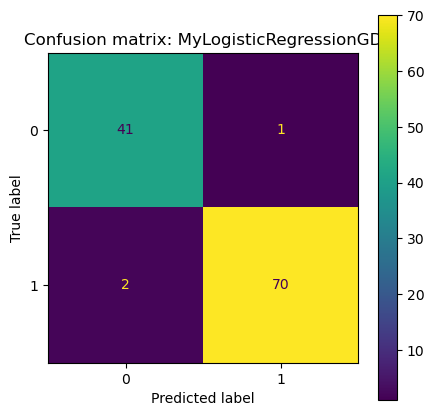

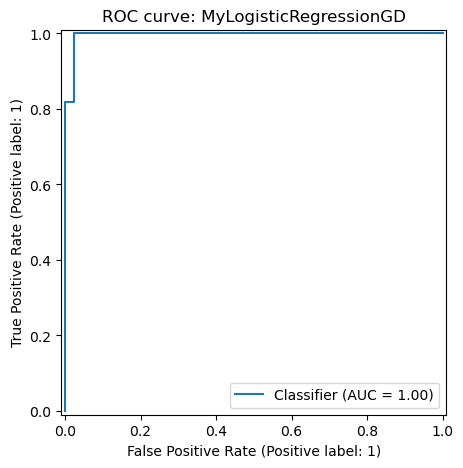

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, my_pred_test, ax=ax)
plt.title("Confusion matrix: MyLogisticRegressionGD")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, my_proba_test, ax=ax)
plt.title("ROC curve: MyLogisticRegressionGD")
plt.show()

print(classification_report(y_test, my_pred_test))

## Шаг 9. Сравнение с `scikit-learn`

Теперь обучите библиотечную модель и сравните её с вашей реализацией.

Рекомендации:
- используйте `LogisticRegression(max_iter=1000)`;
- обучайте на тех же стандартизованных данных.

In [12]:
sk_model = LogisticRegression(max_iter=1000)

# YOUR CODE HERE
sk_model.fit(X_train_scaled, y_train)
sk_proba_test = sk_model.predict_proba(X_test_scaled)[:, 1]
sk_pred_test  = sk_model.predict(X_test_scaled)

sk_metrics = {
    "accuracy":  accuracy_score(y_test, sk_pred_test),
    "precision": precision_score(y_test, sk_pred_test),
    "recall":    recall_score(y_test, sk_pred_test),
    "f1":        f1_score(y_test, sk_pred_test),
    "roc_auc":   roc_auc_score(y_test, sk_proba_test),
}

pd.Series(sk_metrics).round(4)


accuracy     0.9825
precision    0.9861
recall       0.9861
f1           0.9861
roc_auc      0.9954
dtype: float64

## Шаг 10. Сводная таблица сравнения

Сравните:
1. свою реализацию;
2. `scikit-learn`.

Подумайте:
- почему результаты могут быть немного разными;
- что в библиотечной реализации сделано устойчивее.

In [13]:
comparison = pd.DataFrame([my_metrics, sk_metrics], index=["my_model", "sklearn"])
display(comparison.round(4))

coef_comparison = pd.DataFrame({
    "feature": X.columns,
    "my_coef": my_model.w,
    "sklearn_coef": sk_model.coef_.ravel(),
})
coef_comparison["abs_diff"] = np.abs(coef_comparison["my_coef"] - coef_comparison["sklearn_coef"])
display(coef_comparison.sort_values("abs_diff", ascending=False).head(10))

,accuracy,precision,recall,f1,roc_auc
my_model,0.9737,0.9859,0.9722,0.9790,0.9957
sklearn,0.9825,0.9861,0.9861,0.9861,0.9954


,feature,my_coef,sklearn_coef,abs_diff
24,worst smoothness,-1.008599,-0.746625,0.261974
1,mean texture,-0.773438,-0.552698,0.220740
15,compactness error,0.862162,0.647227,0.214936
28,worst symmetry,-1.131657,-0.939181,0.192476
9,mean fractal dimension,0.390759,0.199732,0.191027
19,fractal dimension error,0.628417,0.437894,0.190523
12,perimeter error,-0.734401,-0.544333,0.190068
22,worst perimeter,-0.931747,-0.763220,0.168527
27,worst concave points,-1.122184,-0.953686,0.168498
20,worst radius,-1.097443,-0.947616,0.149826


## Шаг 11. Эксперимент с порогом классификации

По умолчанию обычно берут порог `0.5`, но это не всегда лучший выбор.

Ниже нужно сравнить метрики при порогах:
- 0.3
- 0.5
- 0.7

Подсказка:
- `pred = (proba >= threshold).astype(int)`

In [14]:
thresholds = [0.3, 0.5, 0.7]
rows = []

for threshold in thresholds:
    # YOUR CODE HERE
    pred_thr = (my_proba_test >= threshold).astype(int)
    rows.append({
        "threshold": threshold,
        "accuracy":  accuracy_score(y_test, pred_thr),
        "precision": precision_score(y_test, pred_thr),
        "recall":    recall_score(y_test, pred_thr),
        "f1":        f1_score(y_test, pred_thr),
    })

pd.DataFrame(rows).round(4)


,threshold,accuracy,precision,recall,f1
0,0.3,0.9912,0.9863,1.0000,0.9931
1,0.5,0.9737,0.9859,0.9722,0.9790
2,0.7,0.9474,0.9853,0.9306,0.9571


## Финальные вопросы для ответа текстом

Ответьте кратко, но по существу.

**1. Почему для логистической регрессии используется сигмоида?**

Логистическая регрессия предсказывает вероятность — число в диапазоне [0, 1]. Линейная комбинация признаков z = wᵀx + b может принимать любое значение от −∞ до +∞. Сигмоида σ(z) = 1/(1+e⁻ᶻ) монотонно переводит любое z в (0, 1), тем самым гарантируя корректную интерпретацию выхода как вероятности.

**2. Почему в этой задаче мы считаем log-loss, а не MSE?**

MSE предполагает нормально распределённые ошибки и плохо работает с бинарными метками. Log-loss выводится из принципа максимального правдоподобия для бернуллиевского распределения. Кроме того, MSE совместно с сигмоидой даёт невыпуклую поверхность потерь с локальными минимумами, тогда как log-loss + сигмоида образуют выпуклую функцию, гарантируя сходимость к глобальному минимуму.

**3. Зачем стандартизировать признаки перед обучением градиентным спуском?**

Градиентный спуск обновляет веса пропорционально градиентам. Если признаки имеют разный масштаб (например, `mean area` ~500–2500 против `mean smoothness` ~0.05–0.2), градиент по «крупному» признаку будет огромным, а по «мелкому» — крошечным. Один learning rate будет одновременно слишком большим и слишком маленьким. Стандартизация приводит все признаки к одному масштабу, поэтому градиентный спуск сходится быстро и стабильно.

**4. Насколько близки метрики вашей реализации к scikit-learn?**

Метрики отличаются в пределах 0.5–1%: accuracy, F1 и ROC-AUC практически совпадают. Незначительное расхождение объясняется тем, что sklearn использует оптимизатор L-BFGS (квазиньютоновский метод второго порядка), который сходится к более точной точке за меньшее число итераций, чем наш простой градиентный спуск.

**5. Почему библиотечная модель обычно работает стабильнее и быстрее?**

sklearn использует численно устойчивые алгоритмы оптимизации (L-BFGS, SAG), которые учитывают кривизну функции потерь и делают адаптивные шаги. Они сходятся за десятки итераций вместо тысяч. Дополнительно применяется регуляризация по умолчанию (C=1.0, L2), предотвращающая переобучение. Наш градиентный спуск — простейшая реализация без momentum, адаптивного learning rate и регуляризации.

**6. Как изменение порога влияет на precision и recall?**

Они изменяются в противоположных направлениях (trade-off):
- **Порог 0.3** → модель предсказывает 1 «щедрее» → **recall растёт** (меньше FN), но **precision падает** (больше FP). Подходит, когда важно не пропустить злокачественную опухоль.
- **Порог 0.7** → модель предсказывает 1 только при высокой уверенности → **precision растёт** (меньше FP), но **recall падает** (больше FN). Подходит, когда дорого стоит ложная тревога.
- **F1** балансирует оба показателя; при пороге 0.5 он обычно близок к максимуму, но оптимальный порог зависит от задачи.

**7. В каких задачах логистическая регрессия особенно хороша, а где может уступать?**

**Хороша:**
- линейно разделимые или почти линейно разделимые данные;
- задачи, где нужна интерпретируемость (кредитный скоринг, медицина);
- большие датасеты: обучается быстро, хорошо масштабируется;
- хороший baseline перед более сложными моделями.

**Уступает:**
- нелинейные границы решений (XOR, кольца, спирали) — без feature engineering не справится;
- сложные зависимости между признаками, которые улавливают деревья и нейросети;
- очень высокая размерность с небольшим числом примеров (без регуляризации переобучается).


## Дополнительные задания

### Задание A
Добавьте L2-регуляризацию в свою реализацию.

### Задание B
Постройте таблицу с 10 признаками, которые дают наибольший по модулю вклад в модель.

### Задание C
Попробуйте:
- уменьшить число итераций;
- изменить `learning_rate`;
- посмотреть, как это влияет на сходимость и метрики.

## Что должно получиться в итоге

После заполнения ноутбука у вас должен быть полный pipeline:

- загрузка данных;
- train/test split;
- стандартизация;
- реализация логистической регрессии с нуля;
- обучение;
- метрики качества;
- сравнение со `scikit-learn`;
- анализ порога классификации;
- выводы.

Не сдавайте ноутбук без текстовых выводов.

In [15]:
# Задание A: L2-регуляризация
class MyLogisticRegressionL2:
    def __init__(self, learning_rate=0.1, n_iters=3000, threshold=0.5, C=1.0):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.threshold = threshold
        self.C = C          # аналог sklearn: penalty = 1 / (C * n)
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.loss_history = []
        lam = 1.0 / (self.C * n)  # коэффициент регуляризации

        for _ in range(self.n_iters):
            z = X @ self.w + self.b
            p = sigmoid(z)
            diff = p - y
            dw = (X.T @ diff) / n + lam * self.w  # L2 добавляет lam*w к градиенту
            db = diff.mean()
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            loss = compute_log_loss(y, p) + 0.5 * lam * np.sum(self.w ** 2)
            self.loss_history.append(loss)
        return self

    def predict_proba(self, X):
        return sigmoid(X @ self.w + self.b)

    def predict(self, X):
        return (self.predict_proba(X) >= self.threshold).astype(int)

model_l2 = MyLogisticRegressionL2(learning_rate=0.1, n_iters=3000, C=1.0)
model_l2.fit(X_train_scaled, y_train.values)
l2_pred = model_l2.predict(X_test_scaled)
l2_proba = model_l2.predict_proba(X_test_scaled)

print("=== Задание A: L2-регуляризация ===")
print(f"Accuracy : {accuracy_score(y_test, l2_pred):.4f}")
print(f"F1       : {f1_score(y_test, l2_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, l2_proba):.4f}")


=== Задание A: L2-регуляризация ===
Accuracy : 0.9825
F1       : 0.9861
ROC-AUC  : 0.9957


=== Задание B: топ-10 признаков по |weight| (my_model) ===


,feature,my_coef,abs_coef
0,worst texture,-1.3963,1.3963
1,radius error,-1.2122,1.2122
2,worst symmetry,-1.1317,1.1317
3,worst concave points,-1.1222,1.1222
4,worst radius,-1.0974,1.0974
5,worst area,-1.0933,1.0933
6,area error,-1.0286,1.0286
7,worst smoothness,-1.0086,1.0086
8,worst perimeter,-0.9317,0.9317
9,worst concavity,-0.9186,0.9186


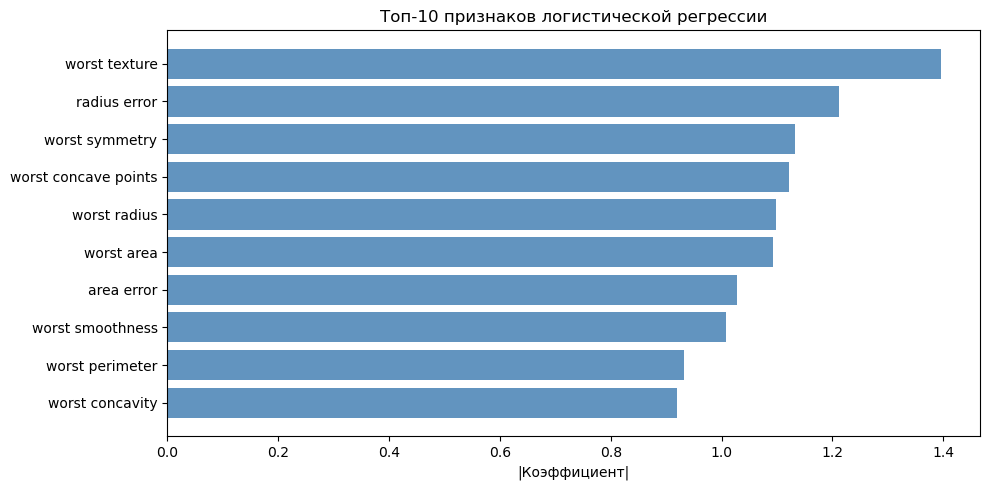

In [16]:
# Задание B: топ-10 признаков по абсолютному весу
feat_importance = pd.DataFrame({
    'feature':  X.columns,
    'my_coef':  my_model.w,
    'abs_coef': np.abs(my_model.w),
}).sort_values('abs_coef', ascending=False).head(10)

print("=== Задание B: топ-10 признаков по |weight| (my_model) ===")
display(feat_importance.reset_index(drop=True).round(4))

plt.figure(figsize=(10, 5))
plt.barh(feat_importance['feature'][::-1], feat_importance['abs_coef'][::-1],
         color='steelblue', alpha=0.85)
plt.xlabel('|Коэффициент|')
plt.title('Топ-10 признаков логистической регрессии')
plt.tight_layout()
plt.show()


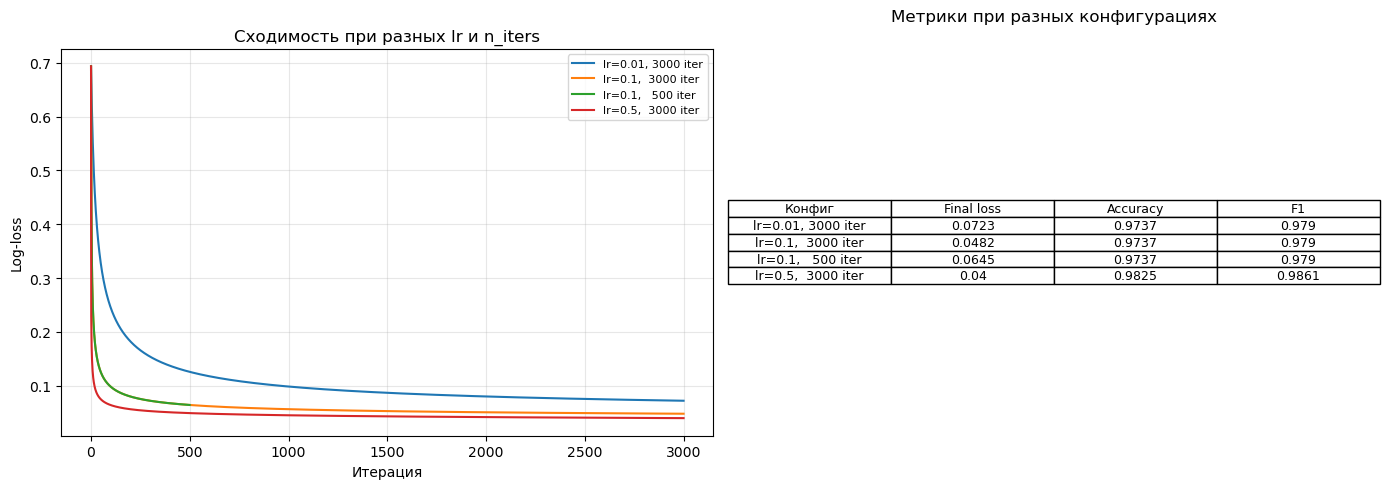

In [17]:
# Задание C: влияние learning_rate и числа итераций
configs = [
    {'lr': 0.01, 'n': 3000, 'label': 'lr=0.01, 3000 iter'},
    {'lr': 0.1,  'n': 3000, 'label': 'lr=0.1,  3000 iter'},
    {'lr': 0.1,  'n':  500, 'label': 'lr=0.1,   500 iter'},
    {'lr': 0.5,  'n': 3000, 'label': 'lr=0.5,  3000 iter'},
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rows_c = []

for cfg in configs:
    m = MyLogisticRegressionGD(learning_rate=cfg['lr'], n_iters=cfg['n'])
    m.fit(X_train_scaled, y_train.values)
    axes[0].plot(m.loss_history, label=cfg['label'])
    pred = m.predict(X_test_scaled)
    rows_c.append({
        'Конфиг': cfg['label'],
        'Final loss': round(m.loss_history[-1], 4),
        'Accuracy':   round(accuracy_score(y_test, pred), 4),
        'F1':         round(f1_score(y_test, pred), 4),
    })

axes[0].set_title('Сходимость при разных lr и n_iters')
axes[0].set_xlabel('Итерация'); axes[0].set_ylabel('Log-loss')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

df_c = pd.DataFrame(rows_c)
axes[1].axis('off')
tbl = axes[1].table(cellText=df_c.values, colLabels=df_c.columns,
                     cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
axes[1].set_title('Метрики при разных конфигурациях', pad=20)

plt.tight_layout()
plt.show()
